**1.Tải thư viện**

In [ ]:
%pip install scikit-learn xgboost matplotlib seaborn joblib

  Using cached scikit_learn-1.9.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (11 kB)
  Using cached xgboost-3.3.0-py3-none-manylinux_2_28_x86_64.whl.metadata (2.0 kB)
  Using cached matplotlib-3.11.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (80 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached scipy-1.18.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
  Using cached narwhals-2.24.0-py3-none-any.whl.metadata (15 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached nvidia_nccl_cu12-2.30.7-py3-none-manylinux_2_18_x86_64.whl.metadata (2.1 kB)
  Using cached contourpy-1.3.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp312-cp312-manylinux2014_x86_64.m

**2.Import thư viện , đọc dữ liệu**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
import joblib


df = pd.read_csv('dataset_raw.csv')
print("Kích thước tập dữ liệu:", df.shape)
df.head()

Kích thước tập dữ liệu: (300, 9)


,query_string,query_length,has_where,has_group_by,has_order_by,has_like,row_count,execution_time_ms,is_slow_query
0,SELECT * FROM customer_transactions WHERE age ...,91,1,0,1,0,237836,1666.270733,1
1,SELECT * FROM customer_transactions WHERE age ...,51,1,0,0,0,793258,5346.591234,1
2,"SELECT status, COUNT(*) FROM customer_transact...",67,0,1,0,0,4,579.446077,1
3,SELECT * FROM customer_transactions ORDER BY t...,79,0,0,1,0,100,299.226999,1
4,SELECT * FROM customer_transactions ORDER BY t...,79,0,0,1,0,100,270.514965,1


**3.Phân tích dữ liệu**

/tmp/ipykernel_1149923/597820140.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='is_slow_query', data=df, palette='viridis')


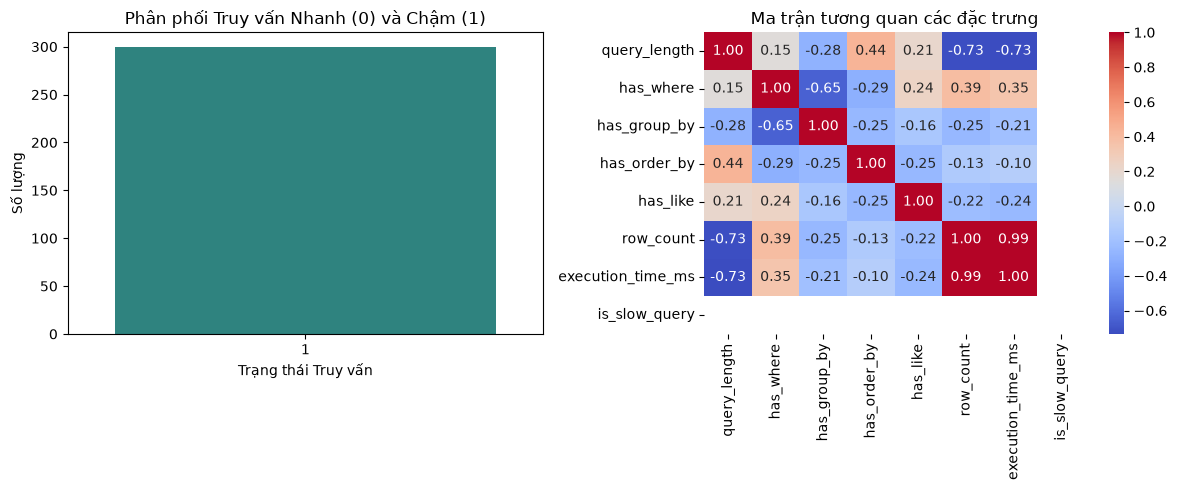

In [3]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(x='is_slow_query', data=df, palette='viridis')
plt.title('Phân phối Truy vấn Nhanh (0) và Chậm (1)')
plt.xlabel('Trạng thái Truy vấn')
plt.ylabel('Số lượng')

plt.subplot(1, 2, 2)
corr_matrix = df.drop(columns=['query_string']).corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Ma trận tương quan các đặc trưng')

plt.tight_layout()
plt.show()

**4.Tiền xử lý dữ liệu**

In [5]:
X = df[['query_length', 'has_where', 'has_group_by', 'has_order_by', 'has_like']]
y = df['is_slow_query']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Số mẫu tập Train: {X_train.shape[0]}")
print(f"Số mẫu tập Test: {X_test.shape[0]}")

Số mẫu tập Train: 240
Số mẫu tập Test: 60


**5.Huyến luyện mô hình**

In [10]:
# 1. Kiểm tra tình trạng hiện tại của nhãn
print("Phân phối nhãn cũ:")
print(df['is_slow_query'].value_counts())

# 2. Cập nhật lại nhãn: Lấy mức thời gian ở giữa (Median) làm ngưỡng phân chia
median_time = df['execution_time_ms'].median()
print(f"\nThời gian chạy trung vị là: {median_time:.2f} ms")

# Bất cứ truy vấn nào chạy lâu hơn mức trung bình này sẽ bị coi là chậm (1)
df['is_slow_query'] = (df['execution_time_ms'] > median_time).astype(int)

print("\nPhân phối nhãn MỚI (đã cân bằng):")
print(df['is_slow_query'].value_counts())

# 3. Chia lại tập Train / Test
X = df[['query_length', 'has_where', 'has_group_by', 'has_order_by', 'has_like']]
y = df['is_slow_query']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("\nĐã cập nhật lại X_train, y_train thành công!")

Phân phối nhãn cũ:
is_slow_query
1    300
Name: count, dtype: int64

Thời gian chạy trung vị là: 426.41 ms

Phân phối nhãn MỚI (đã cân bằng):
is_slow_query
1    150
0    150
Name: count, dtype: int64

Đã cập nhật lại X_train, y_train thành công!


In [11]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)


xgb_model = XGBClassifier(eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)

print("Đã huấn luyện xong Random Forest và XGBoost!")

Đã huấn luyện xong Random Forest và XGBoost!


**6.Đánh giá mô hình**

Random Forest Accuracy: 0.9833
XGBoost Accuracy: 0.9833


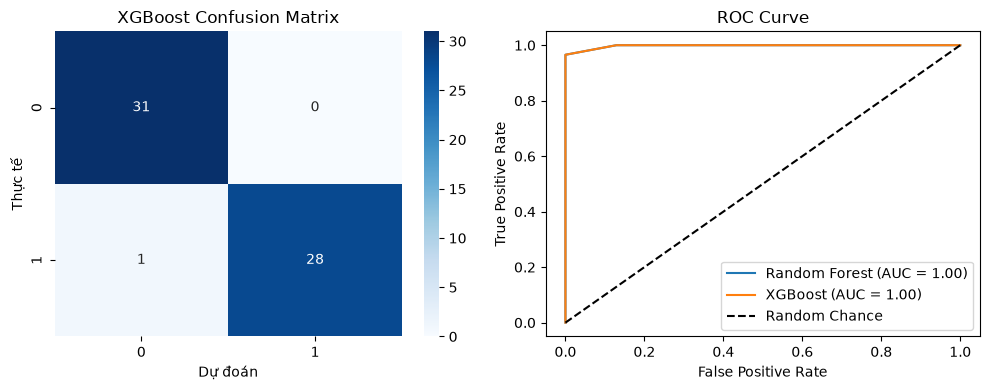


--- Chi tiết phân loại của XGBoost ---
              precision    recall  f1-score   support

           0       0.97      1.00      0.98        31
           1       1.00      0.97      0.98        29

    accuracy                           0.98        60
   macro avg       0.98      0.98      0.98        60
weighted avg       0.98      0.98      0.98        60



In [12]:
# Đánh giá Accuracy
print(f"Random Forest Accuracy: {accuracy_score(y_test, rf_preds):.4f}")
print(f"XGBoost Accuracy: {accuracy_score(y_test, xgb_preds):.4f}")

# Vẽ Confusion Matrix cho XGBoost
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
cm = confusion_matrix(y_test, xgb_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('XGBoost Confusion Matrix')
plt.xlabel('Dự đoán')
plt.ylabel('Thực tế')

# Vẽ đường cong ROC-AUC
plt.subplot(1, 2, 2)
# Lấy xác suất dự đoán (probability)
rf_probs = rf_model.predict_proba(X_test)[:, 1]
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_probs)

plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc(fpr_rf, tpr_rf):.2f})')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc(fpr_xgb, tpr_xgb):.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()

plt.tight_layout()
plt.show()

# In báo cáo chi tiết cho XGBoost
print("\n--- Chi tiết phân loại của XGBoost ---")
print(classification_report(y_test, xgb_preds))

**7.Lưu mô hình tốt nhất**

In [13]:
# Chọn XGBoost làm mô hình chính thức và lưu lại
model_filename = 'sql_predictor.pkl'
joblib.dump(xgb_model, model_filename)

print(f"Đã lưu mô hình thành công vào file: {model_filename}")

Đã lưu mô hình thành công vào file: sql_predictor.pkl
